# Bagging y Random Forest (Regresión)

En este notebook veremos cómo funciona el **bagging** aplicado a árboles de regresión.

 **Idea clave**:
- Un árbol individual puede ser inestable
- Si usamos muchos árboles y promediamos sus predicciones → modelo más robusto

 **Random Forest** = muchos árboles + promedio

In [127]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1. Generación de datos

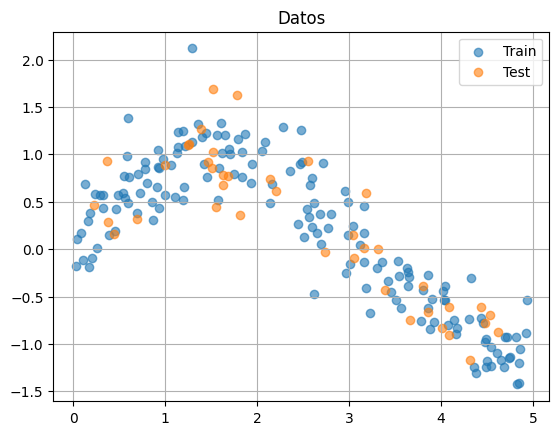

In [128]:
np.random.seed(42)

X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X[:,0]) + 0.3 * np.random.randn(200)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X_train, y_train, alpha=0.6, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.legend(); plt.grid(); plt.title('Datos')
plt.show()

## 2. Árbol individual

In [129]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"MSE árbol: {mse_tree:.4f}")

MSE árbol: 0.1413


## 3. Random Forest (bagging)

In [130]:
rf = RandomForestRegressor(n_estimators=5, max_depth=3, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"MSE Random Forest: {mse_rf:.4f}")

MSE Random Forest: 0.1168


## 4. Comparación visual

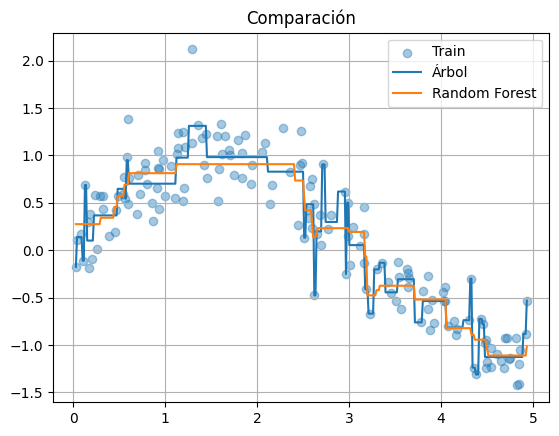

In [131]:
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1,1)

y_tree = tree.predict(X_plot)
y_rf = rf.predict(X_plot)

plt.scatter(X_train, y_train, alpha=0.4, label='Train')
plt.plot(X_plot, y_tree, label='Árbol')
plt.plot(X_plot, y_rf, label='Random Forest')
plt.legend(); plt.grid(); plt.title('Comparación')
plt.show()

## 5. Número de árboles

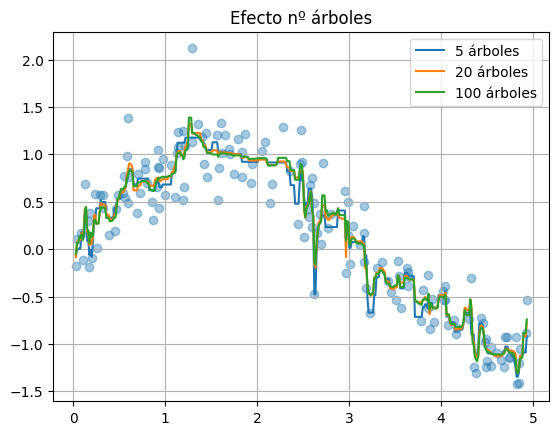

In [132]:
n_list = [5, 20, 100]

plt.scatter(X_train, y_train, alpha=0.4)

for n in n_list:
    model = RandomForestRegressor(n_estimators=n, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f'{n} árboles')

plt.legend(); plt.grid(); plt.title('Efecto nº árboles')
plt.show()

## 6. Conclusiones

- Random Forest combina muchos árboles
- Reduce la variabilidad (más estable)
- Generalmente mejora a un árbol individual

 **Idea clave**: promediar muchos modelos mejora la robustez

## 7. Ejercicios

1. Cambiar `n_estimators`
2. Cambiar `max_depth`
3. Comparar árbol vs random forest
4. Explicar por qué RF es más estable